In [1]:
import os, sys 
import numpy as np
sys.path.insert(0, '../collAIder/')
from model_NN import process_encounters, EncounterRegimeClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score

# Interpolation Dataset #

In [3]:
# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22fplus_20251219_offgrid.csv'
data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only specific columns:
data = data_loaded[:, [1, 2, 3, 4, 5, 8]]
initial_masses = data_loaded[:, [4, 5]]
final_masses = data_loaded[:, [9, 10]]

# Re-assing final masses for merger cases to be all in mass1, otherwise there's a lot of confusion
merger_mask = ((data_loaded[:, 8] == 1) | (data_loaded[:, 8] == -1))
swap_rows = merger_mask & (final_masses[:, 0] == 0) & (final_masses[:, 1] > 0)
final_masses[swap_rows, 0], final_masses[swap_rows, 1] = (final_masses[swap_rows, 1], final_masses[swap_rows, 0])

# Use labels to startify the splits
labels = data[:,-1].astype(np.int64).copy()
labels[labels < 0] = 3 #replace locally the meaning of label -1

ages = data[:,0]
pericenters = data[:,1]
velocities = data[:,2]
masses1 = data[:,3]
masses2 = data[:,4]

# This data set is sampled at these two times, for a total of 1906 collisions
age_interp = [0.002503469]
mask = np.isin(ages, age_interp)

pericenters = pericenters[mask]
velocities = velocities[mask]
masses1 = masses1[mask]
masses2 = masses2[mask]
labels = labels[mask]
final_masses = final_masses[mask]
ages = ages[mask]

print('Size of Dataset: ', len(ages))

# Process all encounters
results = process_encounters(ages, masses1, masses2, pericenters, velocities)
class_results = [p['predicted_class'] for p in results]
reg_results = [p['predicted_values'] for p in results]

# Calculate performance 

balanced_acc = balanced_accuracy_score(labels, class_results)
accuracy = accuracy_score(labels, class_results)

print("Balanced accuracy:", balanced_acc*100)
print("Accuracy:", accuracy*100)

#-- Error metric 2: Absolute Errors 
true_mass1 = [row[0] for row in final_masses]
true_mass2 = [row[1] for row in final_masses]
predicted_mass1 = [row[0] for row in reg_results]
predicted_mass2 = [row[1] for row in reg_results]

true_mass1 = np.array(true_mass1)
true_mass2 = np.array(true_mass2)
predicted_mass1 = np.array(predicted_mass1)
predicted_mass2 = np.array(predicted_mass2)

median_abs_error_m1 = np.median(np.abs(predicted_mass1 - true_mass1)) 
median_abs_error_m2 = np.median(np.abs(predicted_mass2 - true_mass2)) 

#-- Error metric 3: Relative errors for cases where at least one star survives
median_rel_error_m1 = np.median(np.abs(predicted_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(predicted_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])

print(f"The median abs error in m1 is {median_abs_error_m1:.3g}")
print(f"The median abs error in m2 is {median_abs_error_m2}")
print(f"The median rel error in m1 is {median_rel_error_m1:.3g}")
print(f"The median rel error in m2 is {median_rel_error_m2:.3g}")


Size of Dataset:  16


/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:155: RuntimeWarning: divide by zero encountered in scalar divide
  v_p_sq = vinf**2. + 2. * k / (mu * rp)
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:162: RuntimeWarning: invalid value encountered in scalar multiply
  l = mu * rp * v_p # Msun Rsun km/s
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:187: RuntimeWarning: divide by zero encountered in divide
  E_1 =(G * M2**2. / R1) * ((R1/rp)**6. * self.T2(zeta1, n1) + (R1/rp)**8. * self.T3(zeta1, n1))
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:188: RuntimeWarning: divide by zero encountered in divide
  E_2 =(G * M1**2. / R2) * ((R2/rp)**6. * self.T2(zeta2, n2) + (R2/rp)**8. * self.T3(zeta2, n2))


Balanced accuracy: 100.0
Accuracy: 100.0
The median abs error in m1 is 0.0907
The median abs error in m2 is 0.0
The median rel error in m1 is 0.00221
The median rel error in m2 is 0.00358


# Near TAMS Grid #

In [4]:
# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22fplus_20251219_offgrid.csv'
data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only specific columns:
data = data_loaded[:, [1, 2, 3, 4, 5, 8]]
initial_masses = data_loaded[:, [4, 5]]
final_masses = data_loaded[:, [9, 10]]

# Re-assing final masses for merger cases to be all in mass1, otherwise there's a lot of confusion
merger_mask = ((data_loaded[:, 8] == 1) | (data_loaded[:, 8] == -1))
swap_rows = merger_mask & (final_masses[:, 0] == 0) & (final_masses[:, 1] > 0)
final_masses[swap_rows, 0], final_masses[swap_rows, 1] = (final_masses[swap_rows, 1], final_masses[swap_rows, 0])

# Use labels to startify the splits
labels = data[:,-1].astype(np.int64).copy()
labels[labels < 0] = 3 #replace locally the meaning of label -1

# Now create the regression dataset as [M1,f/Mtot,i , M2,f / Mtot,i, Mejec,f / Mtot,i]

ages = data[:,0]
pericenters = data[:,1]
velocities = data[:,2]
masses1 = data[:,3]
masses2 = data[:,4]

# This data set is sampled at this time, for a total of 630 collisions
age_interp = [0.562341325]
mask = np.isin(ages, age_interp)

pericenters = pericenters[mask]
velocities = velocities[mask]
masses1 = masses1[mask]
masses2 = masses2[mask]
labels = labels[mask]
final_masses = final_masses[mask]
ages = ages[mask]

print('Size of Dataset: ', len(ages))

# Process all encounters
results = process_encounters(ages, masses1, masses2, pericenters, velocities)
class_results = [p['predicted_class'] for p in results]
reg_results = [p['predicted_values'] for p in results]

# Calculate performance 

balanced_acc = balanced_accuracy_score(labels, class_results)
accuracy = accuracy_score(labels, class_results)

print("Balanced accuracy:", balanced_acc*100)
print("Accuracy:", accuracy*100)

#-- Error metric 2: Absolute Errors 
true_mass1 = [row[0] for row in final_masses]
true_mass2 = [row[1] for row in final_masses]
predicted_mass1 = [row[0] for row in reg_results]
predicted_mass2 = [row[1] for row in reg_results]

true_mass1 = np.array(true_mass1)
true_mass2 = np.array(true_mass2)
predicted_mass1 = np.array(predicted_mass1)
predicted_mass2 = np.array(predicted_mass2)

median_abs_error_m1 = np.median(np.abs(predicted_mass1 - true_mass1)) 
median_abs_error_m2 = np.median(np.abs(predicted_mass2 - true_mass2)) 

#-- Error metric 3: Relative errors for cases where at least one star survives
median_rel_error_m1 = np.median(np.abs(predicted_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(predicted_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])

print(f"The median abs error in m1 is {median_abs_error_m1:.3g}")
print(f"The median abs error in m2 is {median_abs_error_m2:.3g}")

print(f"The median rel error in m1 is {median_rel_error_m1:.3g}")
print(f"The median rel error in m2 is {median_rel_error_m2:.3g}")



Size of Dataset:  630


/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:155: RuntimeWarning: divide by zero encountered in scalar divide
  v_p_sq = vinf**2. + 2. * k / (mu * rp)
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:162: RuntimeWarning: invalid value encountered in scalar multiply
  l = mu * rp * v_p # Msun Rsun km/s
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:187: RuntimeWarning: divide by zero encountered in divide
  E_1 =(G * M2**2. / R1) * ((R1/rp)**6. * self.T2(zeta1, n1) + (R1/rp)**8. * self.T3(zeta1, n1))
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:188: RuntimeWarning: divide by zero encountered in divide
  E_2 =(G * M1**2. / R2) * ((R2/rp)**6. * self.T2(zeta2, n2) + (R2/rp)**8. * self.T3(zeta2, n2))
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:202: RuntimeWarning: divide by zero encountered in divide
  E_2_n3 =(G * M1**2. / R2) * ((R2/rp)**6. * self.T2(zeta2, n2) + (R2/rp)**8. * self.T3(zeta2, n2))


Balanced accuracy: 89.43483755182
Accuracy: 94.92063492063491
The median abs error in m1 is 0.00863
The median abs error in m2 is 0
The median rel error in m1 is 0.0041
The median rel error in m2 is 0.00437


# Extrapolation Grid #

Size of Dataset:  32


/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:155: RuntimeWarning: divide by zero encountered in scalar divide
  v_p_sq = vinf**2. + 2. * k / (mu * rp)
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:162: RuntimeWarning: invalid value encountered in scalar multiply
  l = mu * rp * v_p # Msun Rsun km/s
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:187: RuntimeWarning: divide by zero encountered in divide
  E_1 =(G * M2**2. / R1) * ((R1/rp)**6. * self.T2(zeta1, n1) + (R1/rp)**8. * self.T3(zeta1, n1))
/projects/b1095/egp8636/ML_SPH/../collAIder/model_NN.py:188: RuntimeWarning: divide by zero encountered in divide
  E_2 =(G * M1**2. / R2) * ((R2/rp)**6. * self.T2(zeta2, n2) + (R2/rp)**8. * self.T3(zeta2, n2))


Balanced accuracy: 78.63247863247862
Accuracy: 84.375
The median abs error in m1 is 1.53
The median abs error in m2 is 0
The median rel error in m1 is 0.0145
The median rel error in m2 is 0.0331


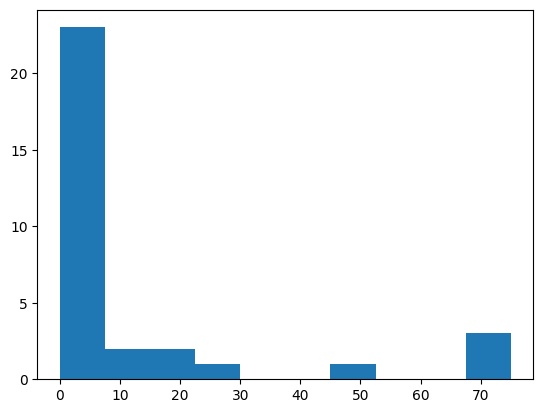

In [5]:
# Extrapolation Grid #

# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22fplus_20251219_offgrid.csv'
data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only specific columns:
data = data_loaded[:, [1, 2, 3, 4, 5, 8]]
initial_masses = data_loaded[:, [4, 5]]
final_masses = data_loaded[:, [9, 10]]

# Re-assing final masses for merger cases to be all in mass1, otherwise there's a lot of confusion
merger_mask = ((data_loaded[:, 8] == 1) | (data_loaded[:, 8] == -1))
swap_rows = merger_mask & (final_masses[:, 0] == 0) & (final_masses[:, 1] > 0)
final_masses[swap_rows, 0], final_masses[swap_rows, 1] = (final_masses[swap_rows, 1], final_masses[swap_rows, 0])

# Use labels to startify the splits
labels = data[:,-1].astype(np.int64).copy()
labels[labels < 0] = 3 #replace locally the meaning of label -1

# Now create the regression dataset as [M1,f/Mtot,i , M2,f / Mtot,i, Mejec,f / Mtot,i]

ages = data[:,0]
pericenters = data[:,1]
velocities = data[:,2]
masses1 = data[:,3]
masses2 = data[:,4]

# This data set is sampled at these two times, for a total
age_interp = [0.000077193, 0.003286100]
mask = np.isin(ages, age_interp)

pericenters = pericenters[mask]
velocities = velocities[mask]
masses1 = masses1[mask]
masses2 = masses2[mask]
labels = labels[mask]
final_masses = final_masses[mask]
ages = ages[mask]

print('Size of Dataset: ', len(ages))

# Process all encounters
results = process_encounters(ages, masses1, masses2, pericenters, velocities)
class_results = [p['predicted_class'] for p in results]
reg_results = [p['predicted_values'] for p in results]

# Calculate performance 

balanced_acc = balanced_accuracy_score(labels, class_results)
accuracy = accuracy_score(labels, class_results)

print("Balanced accuracy:", balanced_acc*100)
print("Accuracy:", accuracy*100)

#-- Error metric 2: Absolute Errors 
true_mass1 = [row[0] for row in final_masses]
true_mass2 = [row[1] for row in final_masses]
predicted_mass1 = [row[0] for row in reg_results]
predicted_mass2 = [row[1] for row in reg_results]

true_mass1 = np.array(true_mass1)
true_mass2 = np.array(true_mass2)
predicted_mass1 = np.array(predicted_mass1)
predicted_mass2 = np.array(predicted_mass2)

median_abs_error_m1 = np.median(np.abs(predicted_mass1 - true_mass1)) 
median_abs_error_m2 = np.median(np.abs(predicted_mass2 - true_mass2)) 

#-- Error metric 3: Relative errors for cases where at least one star survives
median_rel_error_m1 = np.median(np.abs(predicted_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(predicted_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])

print(f"The median abs error in m1 is {median_abs_error_m1:.3g}")
print(f"The median abs error in m2 is {median_abs_error_m2:.3g}")

print(f"The median rel error in m1 is {median_rel_error_m1:.3g}")
print(f"The median rel error in m2 is {median_rel_error_m2:.3g}")

import matplotlib.pyplot as plt
plt.hist(np.abs(predicted_mass1 - true_mass1))
plt.show()

# Testing Grid #

In [7]:
import os, sys 
import numpy as np
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score

data = np.load('./data_splits_splot22f_1215.npz')
X_test = data['X_test']
true_mass1_frac = data['y_test'][:, 1]
true_mass2_frac = data['y_test'][:, 2]
labels =  data['y_test'][:, 0]

# Now create the regression dataset as [M1,f/Mtot,i , M2,f / Mtot,i, Mejec,f / Mtot,i]

ages = 10**(X_test[:,0]) - 0.001
pericenters = 10**(X_test[:,1]) - 0.1
velocities = 10**(X_test[:,2]) - 10
masses1 = np.exp(X_test[:,3])
masses2 = np.exp(X_test[:,4])
print('Size of Dataset: ', len(ages))

# Process all encounters
results = process_encounters(ages, masses1, masses2, pericenters, velocities)
class_results = [p['predicted_class'] for p in results]
reg_results = [p['predicted_values'] for p in results]



Size of Dataset:  4158


In [8]:
# Calculate performance 

balanced_acc = balanced_accuracy_score(labels, class_results)
accuracy = accuracy_score(labels, class_results)

print("Balanced accuracy:", balanced_acc*100)
print("Accuracy:", accuracy*100)

#-- Error metric 2: Absolute Errors 
true_mass1 = [true_mass1_frac[i] * (masses1[i] + masses2[i]) for i in range(len(true_mass1_frac))]
true_mass2 = [true_mass2_frac[i] * (masses1[i] + masses2[i]) for i in range(len(true_mass2_frac))]
predicted_mass1 = [row[0] for row in reg_results]
predicted_mass2 = [row[1] for row in reg_results]

true_mass1 = np.array(true_mass1)
true_mass2 = np.array(true_mass2)
predicted_mass1 = np.array(predicted_mass1)
predicted_mass2 = np.array(predicted_mass2)

median_abs_error_m1 = np.median(np.abs(predicted_mass1 - true_mass1))
median_abs_error_m2 = np.median(np.abs(predicted_mass2 - true_mass2)) 

#-- Error metric 3: Relative errors for cases where at least one star survives
median_rel_error_m1 = np.median(np.abs(predicted_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(predicted_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])

print(f"The median abs error in m1 is {median_abs_error_m1:.3g}")
print(f"The median abs error in m2 is {median_abs_error_m2:.3g}")

print(f"The median rel error in m1 is {median_rel_error_m1:.3g}")
print(f"The median rel error in m2 is {median_rel_error_m2:.3g}")

Balanced accuracy: 98.22576018003718
Accuracy: 98.22029822029822
The median abs error in m1 is 0.00426
The median abs error in m2 is 0
The median rel error in m1 is 0.00106
The median rel error in m2 is 0.00136


In [9]:

regimes = [p['regime_flag'] for p in results]


In [10]:
regimes

[-1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -2,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -2,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -2,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
